# Pandas Part 3: Electricity Mix and Energy Use

This notebook rebuilds the derived metrics needed for the energy sections, then analyzes electricity composition, carbon efficiency profiles, and energy-use intensity.

Links:
- [Pandas index](../data_analytics_project_pandas.ipynb)
- [Shared helpers](../functions.py)

In [1]:
%load_ext autoreload
%autoreload 2
# TODO: Update it to the same level as the polars notebook

In [2]:
from pathlib import Path
import sys

def find_repo_root(start: Path) -> Path:
    for candidate in [start] + list(start.parents):
        if (candidate / 'data' / 'co2_data.csv').exists() and (candidate / 'notebooks' / 'functions.py').exists():
            return candidate
    raise FileNotFoundError('Could not locate the repository root from the current working directory.')

REPO_ROOT = find_repo_root(Path.cwd().resolve())
NOTEBOOKS_DIR = REPO_ROOT / 'notebooks'
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))
DATA_DIR = REPO_ROOT / 'data'

In [3]:
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
import umap.umap_ as umap

import timeit
import requests
import json
from flatten_json import flatten

from functions import (
    apply_correlation_to_df,
    normalize_column,
    z_score_column,
    safe_divide,
    classify_income_group,
    get_top_bottom_n,
    compute_energy_mix_shares,
    plot_dual_axis_timeseries,
    run_kmeans_elbow,
    fetch_wikipedia_gni_table,
    fetch_world_bank_xml_records,
)

# professional theme: clean white grid with muted palette
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "figure.titlesize": 16,
})
%matplotlib inline


/Users/fabianfrank/Documents/carbon_analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## CO2 Emissions Data

We load the Our World in Data CO2 dataset, which contains 79 columns spanning energy mix, land use, and emissions breakdowns. For this analysis we reduce it to five key variables: `country`, `year`, `iso_code`, `population`, and `co2` (total production-based CO2 emissions in millions of tonnes).

Two important filtering steps:
- **Drop rows without `iso_code`**: The dataset includes aggregate entities like "Africa", "OECD", and "World" that lack ISO country codes. Removing these ensures we work exclusively with individual nation-states.
- **Filter to post-1960**: GDP data from the World Bank only begins in 1960, so we align the time range to enable a clean merge later.

In [4]:
co2_df = pd.read_csv(DATA_DIR / 'co2_data.csv')

# choose what columns to keep (can be changed, but this is the most important)
selected_columns = ['country', 'year', 'iso_code', 'population', 'co2']

# drop the columns that are not in the selected_columns list
co2_df = co2_df[selected_columns].copy()

# remove entries with no iso code(Continents and other groups)
co2_df = co2_df[co2_df['iso_code'].notna() & (co2_df['iso_code'].str.strip() != '')]
co2_df = co2_df[co2_df['year'] > 1960]

co2_df


,country,year,iso_code,population,co2
211,Afghanistan,1961,AFG,9214082.0,0.491
212,Afghanistan,1962,AFG,9404410.0,0.689
213,Afghanistan,1963,AFG,9604491.0,0.707
214,Afghanistan,1964,AFG,9814317.0,0.839
215,Afghanistan,1965,AFG,10036003.0,1.007
...,...,...,...,...,...
50406,Zimbabwe,2020,ZWE,15526887.0,8.491
50407,Zimbabwe,2021,ZWE,15797220.0,10.223
50408,Zimbabwe,2022,ZWE,16069061.0,12.232
50409,Zimbabwe,2023,ZWE,16340829.0,13.443


## GDP Data

The World Bank GDP dataset arrives in **wide format** - one column per year (1960, 1961, ..., 2024). This is convenient for spreadsheet viewing but incompatible with tidy-data principles needed for plotting and merging. We use `pd.melt()` to reshape it into long format with one row per country-year observation.

Key steps:
- **Melt** year columns into `year` (int) and `gdp` (numeric) columns
- **Rename** `Country Code` to `iso_code` to create a shared merge key with the CO2 dataset
- **Drop missing GDP values** - not all countries have GDP records for every year, particularly in earlier decades or for newly independent states

In [5]:
# load GDP data
gdp_df = pd.read_csv(DATA_DIR / 'gdp_data.csv')

# reshape from wide to long format
# melt the year columns into rows
year_columns = [col for col in gdp_df.columns if col.isdigit()]
gdp_df = gdp_df.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    value_vars=year_columns,
    var_name='year',
    value_name='gdp'
)

# convert year to integer and gdp to numeric
gdp_df['year'] = gdp_df['year'].astype(int)
gdp_df['gdp'] = pd.to_numeric(gdp_df['gdp'], errors='coerce')

# rename Country Code to iso_code for merging
gdp_df = gdp_df.rename(columns={'Country Code': 'iso_code'})

# keep only the columns we need
gdp_df = gdp_df[['iso_code', 'year', 'gdp']]

# remove rows with missing GDP values
gdp_df = gdp_df.dropna(subset=['gdp'])

gdp_df

,iso_code,year,gdp
1,AFE,1960,2.420569e+10
3,AFW,1960,1.190481e+10
9,ARG,1960,1.586547e+10
13,AUS,1960,1.863568e+10
14,AUT,1960,6.624086e+09
...,...,...,...
17284,WSM,2024,1.175750e+09
17285,XKX,2024,1.119725e+10
17287,ZAF,2024,4.011450e+11
17288,ZMB,2024,2.530319e+10


## Merging the Datasets

We perform a **left join** of GDP onto the CO2 dataframe using `iso_code` and `year` as composite keys. A left join preserves every CO2 record and attaches GDP where available - countries or years without World Bank GDP data simply receive NaN. This is preferable to an inner join because it avoids silently discarding emission records that are still valuable for other analyses.

### Missing Data Heatmap

Before proceeding, we visualize data completeness. The heatmap below shows each variable as a column and each record as a row, with bright cells indicating missing values. This diagnostic is important because it reveals whether missingness is **random** or **systematic** - for instance, GDP data may be consistently absent for certain countries or time periods, which would bias any analysis that silently drops incomplete rows.

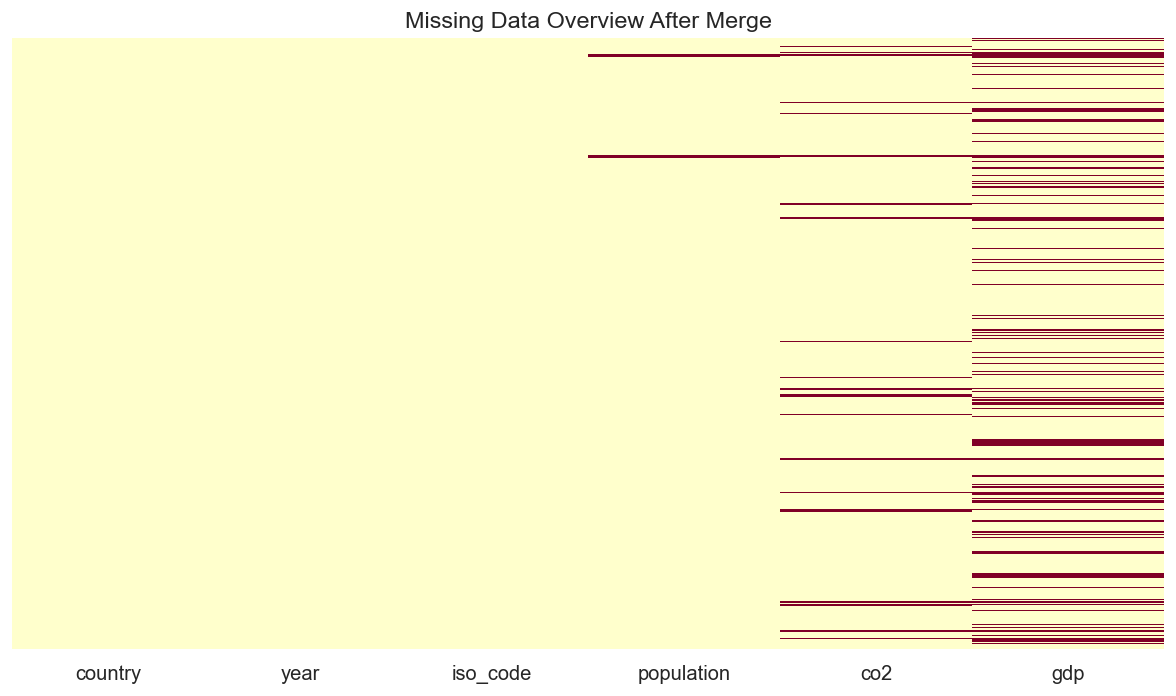

In [6]:
# merge the datasets on iso_code and year
base_df = co2_df.merge(
    gdp_df,
    on=['iso_code', 'year'],
    how='left',
    suffixes=('_co2', '_gdp')
)

# missing data heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(base_df.isnull(), yticklabels=False, cbar=False, cmap='YlOrRd', ax=ax)
ax.set_title("Missing Data Overview After Merge")
plt.tight_layout()
plt.show()


### Data Quality Summary

The GDP column shows the most missingness - this is expected since many countries (especially newly independent or conflict-affected states) lack World Bank GDP records in earlier decades. Importantly, the missingness is **systematic** rather than random: it concentrates in specific countries and time periods. This means any analysis involving GDP will implicitly exclude these observations, so conclusions are most robust for the subset of countries with consistent economic data.

## Per-Capita Metrics

Absolute CO2 and GDP figures are dominated by population size - China and India will always top the charts simply because they have the most people, not necessarily because their economies or industries are more carbon-intensive on a per-person basis. Dividing by population yields **per-capita** values that enable fairer cross-country comparisons: how much does the average citizen emit, and how wealthy is the average citizen?

- **CO2 per capita** is expressed in **tonnes per person** (the raw CO2 column is in millions of tonnes, so we multiply by 10⁶ before dividing by population).
- **GDP per capita** is in **current USD per person**.

We use `np.divide` with a `where` guard to handle zero or missing population entries without raising division errors.

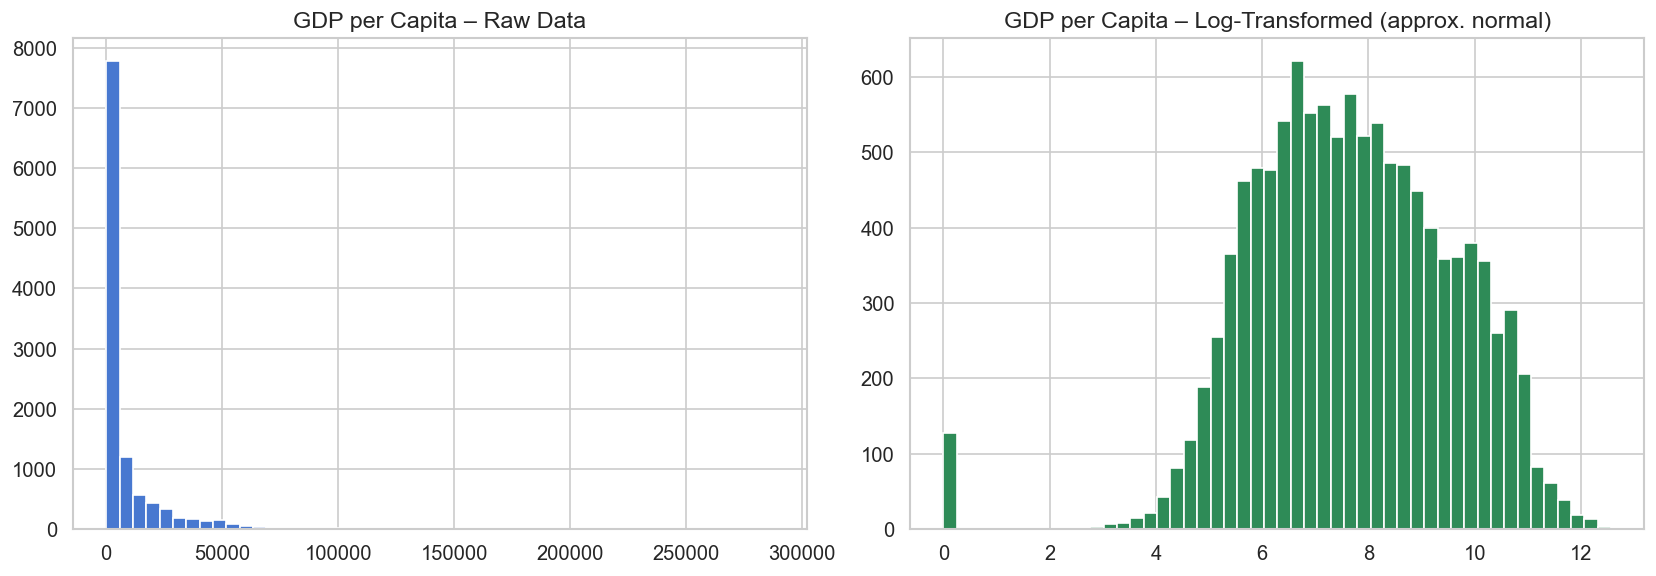

In [7]:
# CO2 is in millions of tonnes; multiply by 1e6 to get tonnes, then divide by population
base_df['co2_per_capita'] = safe_divide(base_df['co2'].values * 1e6, base_df['population'].values)
base_df['gdp_per_capita'] = safe_divide(base_df['gdp'].values, base_df['population'].values)

# Log-transform per-capita metrics for better visualization
base_df['log_gdp_pc'] = np.log1p(base_df['gdp_per_capita'].values)
base_df['log_co2_pc'] = np.log1p(base_df['co2_per_capita'].values)

# compare raw and log-transformed data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(base_df['gdp_per_capita'].dropna(), bins=50, edgecolor='white')
axes[0].set_title('GDP per Capita – Raw Data')
axes[1].hist(base_df['log_gdp_pc'].dropna(), bins=50, edgecolor='white', color='seagreen')
axes[1].set_title('GDP per Capita – Log-Transformed (approx. normal)')
plt.tight_layout()
plt.show()


## Income Group Classification

To move beyond individual country case studies, we classify each observation by **income group** using the World Bank's Gross National Income (GNI) thresholds:

| Group | GNI per capita (current USD) |
|---|---|
| Low | $\leq$ 1,145 |
| Lower-Middle | 1,146 – 4,515 |
| Upper-Middle | 4,516 – 14,005 |
| High | $>$ 14,005 |

Source: [World Bank Country Classification (FY2025)](https://datahelpdesk.worldbank.org/knowledgebase/articles/906519-world-bank-country-and-lending-groups)

This allows us to ask a structural question: do emission trajectories differ systematically between rich and poor countries? We scrape current GNI per capita figures from Wikipedia and merge them onto our dataset, then apply `pd.cut` to assign income brackets based on GDP per capita as a proxy.

In [8]:
url = 'https://en.wikipedia.org/wiki/List_of_countries_by_GNI_(nominal)_per_capita'

# pd.read_html would have been possible too
# but BeautifulSoup gives us more control over the wikipedia table structure
gni_df = fetch_wikipedia_gni_table(url)

gni_df


,,Country,gni_per_capita,Year
0,,Country,1.0,Year
1,,High Income Economies,NaN,2024
2,–,Bermuda (UK),145150.0,2024
3,1,Liechtenstein,116600.0,2009
4,2,Norway,98170.0,2024
...,...,...,...,...
208,187,Madagascar,510.0,2024
209,188,Yemen,470.0,2024
210,189,Afghanistan,370.0,2023
211,190,South Sudan,350.0,2024


In [9]:
# normalize 
gni_df['country_clean'] = normalize_column('Country', gni_df)
base_df['country_clean'] = normalize_column('country', base_df)

# left merge
main_df = pd.merge(base_df, gni_df[['country_clean', 'gni_per_capita']], 
                     on='country_clean', how='left')

# classify income groups using World Bank thresholds
main_df['income_group'] = classify_income_group(main_df['gni_per_capita'])

main_df

,country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,log_gdp_pc,log_co2_pc,country_clean,gni_per_capita,income_group
0,Afghanistan,1961,AFG,9214082.0,0.491,NaN,0.053288,NaN,NaN,0.051917,afghanistan,370.0,Low
1,Afghanistan,1962,AFG,9404410.0,0.689,NaN,0.073264,NaN,NaN,0.070704,afghanistan,370.0,Low
2,Afghanistan,1963,AFG,9604491.0,0.707,NaN,0.073611,NaN,NaN,0.071028,afghanistan,370.0,Low
3,Afghanistan,1964,AFG,9814317.0,0.839,NaN,0.085487,NaN,NaN,0.082029,afghanistan,370.0,Low
4,Afghanistan,1965,AFG,10036003.0,1.007,NaN,0.100339,NaN,NaN,0.095618,afghanistan,370.0,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13947,Zimbabwe,2020,ZWE,15526887.0,8.491,3.198033e+10,0.546858,2059.674586,7.630789,0.436226,zimbabwe,2260.0,Lower-Middle
13948,Zimbabwe,2021,ZWE,15797220.0,10.223,4.128767e+10,0.647139,2613.603766,7.868868,0.499040,zimbabwe,2260.0,Lower-Middle
13949,Zimbabwe,2022,ZWE,16069061.0,12.232,4.075756e+10,0.761214,2536.399713,7.838895,0.566004,zimbabwe,2260.0,Lower-Middle
13950,Zimbabwe,2023,ZWE,16340829.0,13.443,3.587178e+10,0.822663,2195.223980,7.694495,0.600299,zimbabwe,2260.0,Lower-Middle


In [ ]:
# Carbon intensity setup extracted from the original timing cell.
# carbon intensity: CO2 (millions of tonnes) per $1M GDP
gdp_in_millions = main_df['gdp'].values / 1_000_000
main_df['co2_per_gdp'] = safe_divide(main_df['co2'].values, gdp_in_millions)

# keep working from the enriched dataframe from here on
# this way later cells still have income groups and carbon intensity
base_df = main_df.copy()


In [11]:
# fetch electricity production data from Our World in Data
df_electricity = pd.read_csv(
    "https://ourworldindata.org/grapher/electricity-prod-source-stacked.csv?v=1&csvType=full&useColumnShortNames=true",
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)

# rename to concise column names
rename_map = {
    'code': 'iso_code',
    "other_renewables_excluding_bioenergy_generation__twh_chart_electricity_prod_source_stacked": "other_renewables",
    'bioenergy_generation__twh_chart_electricity_prod_source_stacked': 'bioenergy',
    'solar_generation__twh_chart_electricity_prod_source_stacked': 'solar',
    'wind_generation__twh_chart_electricity_prod_source_stacked': 'wind',
    'hydro_generation__twh_chart_electricity_prod_source_stacked': 'hydro',
    'nuclear_generation__twh_chart_electricity_prod_source_stacked': 'nuclear',
    'oil_generation__twh_chart_electricity_prod_source_stacked': 'oil',
    'gas_generation__twh_chart_electricity_prod_source_stacked': 'gas',
    'coal_generation__twh_chart_electricity_prod_source_stacked': 'coal',
}
df_electricity = df_electricity.rename(columns=rename_map)

# keep only individual countries (drop aggregates without ISO codes)
df_electricity = df_electricity[df_electricity['iso_code'].notna() & (df_electricity['iso_code'].str.strip() != '')]

print(f"Electricity data: {df_electricity.shape[0]:,} rows, "
      f"{df_electricity['iso_code'].nunique()} countries, "
      f"{df_electricity['year'].min()}-{df_electricity['year'].max()}")

df_electricity

Electricity data: 6,197 rows, 219 countries, 1985-2025


,entity,iso_code,year,other_renewables,bioenergy,solar,wind,hydro,nuclear,oil,gas,coal
26,Afghanistan,AFG,2000,0.0,0.00,0.00,0.0,0.31,0.0,0.17,0.0,0.00
27,Afghanistan,AFG,2001,0.0,0.00,0.00,0.0,0.50,0.0,0.15,0.0,0.04
28,Afghanistan,AFG,2002,0.0,0.00,0.00,0.0,0.56,0.0,0.11,0.0,0.04
29,Afghanistan,AFG,2003,0.0,0.00,0.00,0.0,0.63,0.0,0.19,0.0,0.09
30,Afghanistan,AFG,2004,0.0,0.00,0.00,0.0,0.56,0.0,0.17,0.0,0.06
...,...,...,...,...,...,...,...,...,...,...,...,...
6874,Zimbabwe,ZWE,2020,0.0,0.10,0.02,0.0,3.81,0.0,0.04,0.0,2.74
6875,Zimbabwe,ZWE,2021,0.0,0.11,0.02,0.0,5.93,0.0,0.00,0.0,2.51
6876,Zimbabwe,ZWE,2022,0.0,0.11,0.03,0.0,5.88,0.0,0.00,0.0,2.92
6877,Zimbabwe,ZWE,2023,0.0,0.12,0.03,0.0,5.46,0.0,0.00,0.0,4.38


In [12]:
green_cols = ['other_renewables', 'bioenergy', 'solar', 'wind', 'hydro', 'nuclear']
non_green_cols = ['coal', 'oil', 'gas']

df_electricity = compute_energy_mix_shares(df_electricity, green_cols, non_green_cols)

In [ ]:
# start from the enriched dataframe, not the pre-income-group version
base_df = main_df.copy()

# columns coming from df_electricity (excluding merge keys and entity)
elec_cols = [c for c in df_electricity.columns if c not in ['entity', 'iso_code', 'year']]

# drop these from base_df if they already exist (handles notebook re-runs)
base_df = base_df.drop(columns=[c for c in elec_cols if c in base_df.columns])

# merge electricity data onto base_df
base_df = base_df.merge(
    df_electricity.drop(columns=['entity']),
    on=['iso_code', 'year'],
    how='inner'
)

base_df


# Electricity Mix and Carbon Intensity

Even today, coal remains one of the most widely used sources of electricity globally. Due to its large CO2 footprint, many countries struggle with pollution and carbon emissions.

Especially former Soviet republics and countries in the Central Asian region capitalise on their vast coal reserves and use them as their primary source of electricity. That, combined with generally smaller populations, typically leads to higher CO2 per GDP. This relationship between electricity mix and carbon intensity is explored below.

In [ ]:
# identify the 5 most and least carbon-efficient countries (by mean co2_per_gdp)
required_cols = ['co2_per_gdp', 'non_green_share']
missing_efficiency_cols = [col for col in required_cols if col not in base_df.columns]
if missing_efficiency_cols:
    raise KeyError(f"Missing columns: {missing_efficiency_cols}. Re-run the carbon-intensity and electricity-merge cells above.")

valid_efficiency = base_df[base_df['co2_per_gdp'] > 0]
top5_efficient = valid_efficiency.groupby('iso_code')['co2_per_gdp'].mean().nsmallest(5).index
top5_inefficient = valid_efficiency.groupby('iso_code')['co2_per_gdp'].mean().nlargest(5).index

countries_to_plot = list(top5_efficient) + list(top5_inefficient)
plot_df = base_df[base_df['iso_code'].isin(countries_to_plot)].copy()

plot_df['efficiency'] = plot_df['iso_code'].apply(
    lambda x: 'Most Efficient' if x in top5_efficient else 'Least Efficient'
)

# order: efficient first (top row), inefficient second (bottom row)
efficient_countries = plot_df[plot_df['efficiency'] == 'Most Efficient']['country'].unique()
inefficient_countries = plot_df[plot_df['efficiency'] == 'Least Efficient']['country'].unique()
col_order = list(efficient_countries) + list(inefficient_countries)

g = sns.relplot(
    data=plot_df,
    x='year', y='non_green_share',
    hue='efficiency', style='efficiency',
    col='country', col_wrap=5,
    col_order=col_order,
    kind='line', height=3, aspect=1.2,
    palette={'Most Efficient': 'seagreen', 'Least Efficient': 'firebrick'},
    facet_kws={'xlim': (2000, 2024), 'ylim': (0, 1.05)}
)
g.set_titles("{col_name}")
g.set_axis_labels("Year", "Non-Green Electricity Share")
g.fig.suptitle("Fossil Fuel Dependency: Most vs Least Carbon-Efficient Economies", y=1.02, fontsize=14)
plt.show()


### Electricity Mix: Key Observations

Looking at the most and least efficient countries in terms of CO2 per GDP, a clear trend emerges: the more efficient a country is, the lower its share of non-green energy.

However, several anomalies stand out:

- **Bermuda** has a ~100% non-green electricity share but is deemed carbon-efficient. This is because its exceptionally high GDP (driven by financial services) means that its modest electricity emissions barely register per dollar of output.
- **South Sudan** appears efficient for the opposite reason - most of the population lacks grid electricity entirely and relies on burning wood or waste, neither of which is captured in this dataset.
- **Ukraine**, despite not having the highest share of non-green electricity, struggles with carbon efficiency due to ageing Soviet-era industrial infrastructure and, more recently, the economic impact of the ongoing war. A declining population also pushes CO2 per GDP upward.

# Energy-Usage per capita

### Integrating External XML Data

To demonstrate XML data processing, an additional dataset was retrieved
from the World Bank API containing energy consumption per capita.

The XML structure was parsed and converted into a pandas DataFrame.
Relevant fields were extracted and merged with the main dataset.

Energy consumption is conceptually related to carbon emissions and
therefore provides an additional explanatory variable for later
machine learning models.

In [ ]:
# fetch xml data from worldbank.org(energy use per capita)
url = 'https://api.worldbank.org/v2/country/all/indicator/EG.USE.PCAP.KG.OE?format=xml&per_page=20000'

# pd.read_xml would have been possible too
# but parsing the xml ourselves makes the structure more explicit
energy_xml = fetch_world_bank_xml_records(url)

# only keep the fields we actually need for the merge later
energy_xml = energy_xml[[
    "countryiso3code",
    "date",
    "value"
]].rename(columns={
    "countryiso3code": "iso_code",
    "date": "year",
    "value": "energy_use_pc"
})

# years come in as text from the xml response
energy_xml["year"] = energy_xml["year"].astype(int)

energy_xml


In [ ]:
# merge
main_df = main_df.merge(
    energy_xml,
    on=["iso_code","year"],
    how="left"
)

main_df

In [ ]:
# mean the countries, so there are no duplicates from multiple years
mean_df = (
    main_df.groupby(["iso_code", "income_group"])
      .agg(
          energy_use_pc=("energy_use_pc", "mean"),
          co2_per_capita=("co2_per_capita", "mean"),
          gdp_per_capita=("gdp_per_capita", "mean")
      )
      .reset_index()
)


fig, ax = plt.subplots(figsize=(12, 6))

# plot a scatterplot to display energy use per capita and co2 per capita
sns.scatterplot(
    data=mean_df,
    x="energy_use_pc",
    y="co2_per_capita",
    hue="income_group",
    alpha=0.3,
    ax = ax
)

# use a regression plot to show trends
sns.regplot(
    data=mean_df,
    x="energy_use_pc",
    y="co2_per_capita",
    scatter=False,
    color="red",
    ax = ax
)


plt.xlabel("Energy use per capita (kg oil equivalent)")
plt.ylabel("CO2 emissions per capita")
plt.title("Relationship between energy consumption and CO2 emissions")

plt.tight_layout()
plt.show()


# Correlation between energy usage and CO₂ emissions per capita

The country-level aggregation reveals a strong positive relationship between energy consumption per capita and CO₂ emissions per capita. This suggests that differences in energy demand across countries play a significant role in explaining variations in emissions.

High-income countries generally show higher energy consumption levels, while low-income countries cluster in the lower-left region of the plot. This pattern reflects the strong link between economic development, energy demand, and emissions.

To avoid distortions caused by extreme single-year observations, the dataset was aggregated at the country level by calculating mean values across all available years. This allows the visualisation to focus on structural differences between countries rather than short-term fluctuations.
